### Import modules and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Setting up the path to include the parent directory
sys.path.append(str(Path.cwd().parent.parent))
from backend.config.settings import PATHS
from backend.data.cleaning import clean_string_series

In [2]:
reservoir_path = PATHS['pre_EDA'] / 'detailed_reservoir_for_EDA.csv'
detailed_reservoirs_pd = pd.read_csv(reservoir_path)
detailed_reservoirs_pd.head()

,code,name,reservoir,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
0,9250031,sallente,sallente,42.500371,0.991460,ebro,barranc lora,NaN,NaN,NaN,lleida,cataluna,presa materiales sueltos pantalla asfaltica,1770.0,89.00,https://sig.mapama.gob.es/WebServices/clientew...
1,3450047,cazalegas,cazalegas dam,40.012987,-4.706248,tajo,rio alberche,https://www.google.com/search?kgmid=/g/11dfr4j268,NaN,https://www.wikidata.org/wiki/Q30278314,toledo,castilla mancha,presa materiales sueltos pantalla hormigon,NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
2,9250014,lago negro,lago negro,42.542286,1.040582,ebro,NaN,NaN,NaN,NaN,lleida,cataluna,presa materiales sueltos zonificada o nucleo,2340.0,11.00,https://sig.mapama.gob.es/WebServices/clientew...
3,9500034,torcas,trocas reservoir,41.294686,-1.087447,ebro,rio huerva,NaN,NaN,https://www.wikidata.org/wiki/Q23991169,zaragoza,aragon,presa fabrica gravedad (hormigon vibrado),624.8,39.45,https://sig.mapama.gob.es/WebServices/clientew...
4,3190006,bujeda,bujeda,40.244501,-2.835188,tajo,sin nombre,NaN,NaN,NaN,guadalajara,castilla mancha,presa materiales sueltos homogenea,905.5,39.50,https://sig.mapama.gob.es/WebServices/clientew...


### Correlations Matrix between Features

In [27]:
correlation_matrix = detailed_reservoirs_pd.select_dtypes(include=[np.number]).corr()

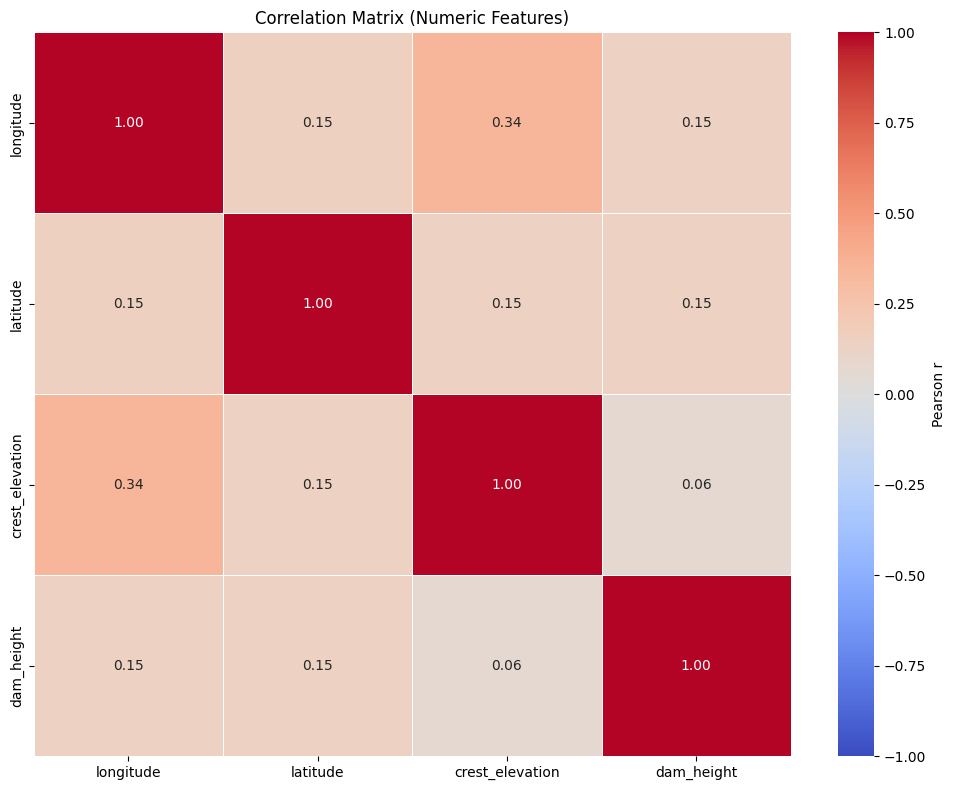

In [28]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',        
    annot=True,
    fmt='.2f',
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

As we can see, there isn't a strong (linear) correlation between features


### Analyzing code column

In [3]:
print(f"Out of {len(detailed_reservoirs_pd)} rows, there are {detailed_reservoirs_pd['code'].nunique()} code unique ones.")

Out of 367 rows, there are 367 code unique ones.


We already have the id, so this column can be deleted

### Selection between name and reservoir column

We start getting those values that are different

In [5]:
different_values = detailed_reservoirs_pd[(detailed_reservoirs_pd['name'] == detailed_reservoirs_pd['reservoir']) == False]
different_values.head()

,name,reservoir,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
1,cazalegas,cazalegas dam,40.012987,-4.706248,tajo,rio alberche,https://www.google.com/search?kgmid=/g/11dfr4j268,NaN,https://www.wikidata.org/wiki/Q30278314,toledo,castilla mancha,presa materiales sueltos pantalla hormigon,NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
3,torcas,trocas reservoir,41.294686,-1.087447,ebro,rio huerva,NaN,NaN,https://www.wikidata.org/wiki/Q23991169,zaragoza,aragon,presa fabrica gravedad (hormigon vibrado),624.8,39.45,https://sig.mapama.gob.es/WebServices/clientew...
8,almoguera,faltos,40.274306,-2.958820,tajo,rio tajo,https://www.google.com/search?kgmid=/g/12283wdk,NaN,https://www.wikidata.org/wiki/Q5672943,guadalajara,castilla mancha,presa fabrica gravedad (hormigon vibrado),NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
9,bachimana alto,bachimana alto reservoir,42.782028,-0.223491,ebro,rio caldares,NaN,NaN,https://www.wikidata.org/wiki/Q95674644,huesca,aragon,presa fabrica mamposteria,2207.1,38.10,https://sig.mapama.gob.es/WebServices/clientew...
10,jarosa,jarosa reservoir,40.664970,-4.117563,tajo,arroyo jarosa,NaN,NaN,https://www.wikidata.org/wiki/Q1329216,madrid,comunidad madrid,presa fabrica gravedad (hormigon vibrado),1088.0,54.00,https://sig.mapama.gob.es/WebServices/clientew...


Seems like reservoir has more useless stopwords, let's investigate further.

In [6]:
print(f"Number of rows in 'name' column containing specific stopwords: {detailed_reservoirs_pd['name'].str.contains('reservoir|dam|embalse').sum()}\n")
print(f"Number of rows in 'reservoir' column containing specific stopwords: {detailed_reservoirs_pd['reservoir'].str.contains('reservoir|dam|embalse').sum()}\n")

Number of rows in 'name' column containing specific stopwords: 0

Number of rows in 'reservoir' column containing specific stopwords: 179



Let's study how many rows of each column match the names from the reservoir dataframe

In [7]:
reservoirs_path = PATHS['cleaned_data_notebooks'] / 'reservoirs_cleaned.csv'
reservoirs = pd.read_csv(reservoirs_path)
reservoirs.head()

,id,scope,name,capacity,electric_flag
0,1,guadalquivir,brena,103.0,0
1,3,guadalquivir,fernandina,247.0,0
2,5,guadalquivir,puebla cazalla,87.0,0
3,6,guadalquivir,pedro marin,19.0,0
4,9,cuenca mediterranea andaluza,vinuela,170.0,0


In [8]:
column_name = detailed_reservoirs_pd['name']
name_merged = pd.merge(column_name, reservoirs, left_on='name', right_on='name', how='inner')
print(f"Number of rows in 'name' column matching names from reservoir dataframe: {len(name_merged)}")

Number of rows in 'name' column matching names from reservoir dataframe: 312


In [9]:
column_reservoir = clean_string_series(detailed_reservoirs_pd['reservoir'].str.replace('reservoir|dam|embalse', '', regex=True))
reservoir_merged = pd.merge(column_reservoir, reservoirs, left_on='reservoir', right_on='name', how='inner')
print(f"Number of rows in 'reservoir' column matching names from reservoir dataframe: {len(reservoir_merged)}")

Number of rows in 'reservoir' column matching names from reservoir dataframe: 296


As there are more reservoirs matching with name column, reservoir will be dropped

### Study of correctness of string data

For the column basin:

In [11]:
detailed_reservoirs_pd['basin'].unique()

array(['ebro', 'tajo', 'guadiana', 'duero', 'guadalete y barbate',
       'guadalquivir', 'cantabrico oriental', 'segura',
       'cuencas internas cataluna', 'mino sil', 'jucar', 'galicia costa',
       'tinto  odiel y piedras', 'cantabrico occidental',
       'cuencas mediterraneas andaluzas'], dtype=object)

They are all valid values.

For the column riverbed:

In [12]:
detailed_reservoirs_pd.loc[detailed_reservoirs_pd['riverbed'].str.contains('rio|arroyo|rivera|riu|riera|rambla|barranc', regex=True) == False,'riverbed'].unique()

array(['sin nombre', 'regato rosal', 'urrestilla ibaia',
       'regato valdegollado', 'noguera tor', 'val fuente ferial',
       'txaeta erreka', 'anarbe ibaia o enobietaku erreka',
       'santa engracia itsasadar', 'llobregat', 'còrrec', 'muga',
       'noguera pallaresa', 'zadorra ibaia'], dtype=object)

As we can see, the first one is 'sin nombre', that means 'without name' in Spanish, so it will have to be converted to nan when cleaning the data.

The columns province and autonomous_community will be checked more deeply at merges.ipynb

The column type:

In [13]:
detailed_reservoirs_pd['type'].unique()

array(['presa materiales sueltos pantalla asfaltica',
       'presa materiales sueltos pantalla hormigon',
       'presa materiales sueltos zonificada o nucleo',
       'presa fabrica gravedad (hormigon vibrado)',
       'presa materiales sueltos homogenea',
       'presa fabrica contrafuertes', 'presa fabrica mamposteria',
       'presa fabrica boveda',
       'presa fabrica gravedad (hormigon compactado)', 'presa mixta',
       'presa fabrica arco gravedad',
       'presa materiales sueltos pantalla material sintetico'],
      dtype=object)

Every value is correct in this case

### Study of Missing Values

In [14]:
detailed_reservoirs_pd.isna().sum()

name                      0
longitude                 0
latitude                  0
basin                     0
riverbed                  8
google                  252
openstreetmap           331
wikidata                180
province                  0
autonomous_community      0
type                      0
crest_elevation         183
dam_height              183
report                    0
dtype: int64

#### Riverbed Column

In [15]:
non_nan_riverbed = detailed_reservoirs_pd[detailed_reservoirs_pd['riverbed'].notna()]
non_nan_riverbed_column = non_nan_riverbed['riverbed']
print(f"There are {len(non_nan_riverbed_column)} riverbeds, and {non_nan_riverbed_column.nunique()} are different")

There are 359 riverbeds, and 242 are different


Let's get those that are at least repeated 3 times

In [16]:
non_nan_riverbed[non_nan_riverbed_column.map(non_nan_riverbed_column.value_counts() > 2)].sort_values('riverbed')

,name,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
364,iznajar,37.276153,-4.386873,guadalquivir,rio genil,NaN,NaN,https://www.wikidata.org/wiki/Q5369447,cordoba,andalucia,presa fabrica gravedad (hormigon vibrado),426.00,121.60,https://sig.mapama.gob.es/WebServices/clientew...
192,cordobilla,37.349256,-4.721161,guadalquivir,rio genil,NaN,NaN,NaN,sevilla,andalucia,presa fabrica gravedad (hormigon vibrado),218.25,45.25,https://sig.mapama.gob.es/WebServices/clientew...
250,canales,37.160469,-3.480476,guadalquivir,rio genil,NaN,NaN,https://www.wikidata.org/wiki/Q1032728,granada,andalucia,presa materiales sueltos zonificada o nucleo,NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
33,malpasillo jauja,37.299151,-4.676820,guadalquivir,rio genil,NaN,NaN,NaN,cordoba,andalucia,presa fabrica contrafuertes,250.00,36.00,https://sig.mapama.gob.es/WebServices/clientew...
148,sierra boyera,38.260807,-5.221643,guadalquivir,rio guadiato,NaN,NaN,https://www.wikidata.org/wiki/Q5369459,cordoba,andalucia,presa materiales sueltos zonificada o nucleo,503.50,10.25,https://sig.mapama.gob.es/WebServices/clientew...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,minilla,37.664791,-6.185621,guadalquivir,rivera huelva,NaN,NaN,NaN,sevilla,andalucia,presa fabrica gravedad (hormigon vibrado),NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
198,gergal,37.567273,-6.049054,guadalquivir,rivera huelva,NaN,NaN,NaN,sevilla,andalucia,presa fabrica arco gravedad,NaN,NaN,https://sig.mapama.gob.es/WebServices/clientew...
333,pedrera,38.032751,-0.875544,segura,sin nombre,NaN,NaN,NaN,alacant alicante,comunitat valenciana,presa materiales sueltos homogenea,110.54,65.54,https://sig.mapama.gob.es/WebServices/clientew...
4,bujeda,40.244501,-2.835188,tajo,sin nombre,NaN,NaN,NaN,guadalajara,castilla mancha,presa materiales sueltos homogenea,905.50,39.50,https://sig.mapama.gob.es/WebServices/clientew...


As we can observe, repeated riverbeds tend to have similar longitude and/or latitude values, so we will impute missing values based on the closest non-null riverbed.

### Crest Elevation Column

We carry out the same study as with riverbeds, in case there are reservoirs with the same exact crest elevation:

In [17]:
non_nan_crest = detailed_reservoirs_pd[detailed_reservoirs_pd['crest_elevation'].notna()]
non_nan_crest_column = non_nan_crest['crest_elevation']
non_nan_crest[non_nan_crest_column.map(non_nan_crest_column.value_counts() > 2)].sort_values(by='crest_elevation')

,name,longitude,latitude,basin,riverbed,google,openstreetmap,wikidata,province,autonomous_community,type,crest_elevation,dam_height,report
332,pedrera,38.031900,-0.866921,segura,arroyo grande,NaN,NaN,NaN,alacant alicante,comunitat valenciana,presa materiales sueltos homogenea,110.54,30.04,https://sig.mapama.gob.es/WebServices/clientew...
333,pedrera,38.032751,-0.875544,segura,sin nombre,NaN,NaN,NaN,alacant alicante,comunitat valenciana,presa materiales sueltos homogenea,110.54,65.54,https://sig.mapama.gob.es/WebServices/clientew...
334,pedrera,38.032818,-0.870301,segura,arroyo grande,NaN,NaN,NaN,alacant alicante,comunitat valenciana,presa materiales sueltos homogenea,110.54,35.04,https://sig.mapama.gob.es/WebServices/clientew...
335,pedrera,38.020914,-0.886309,segura,rambla alcorisa,NaN,NaN,NaN,alacant alicante,comunitat valenciana,presa materiales sueltos homogenea,110.54,25.04,https://sig.mapama.gob.es/WebServices/clientew...
268,sotonera,42.102575,-0.676812,ebro,arroyo aston vacas,https://www.google.com/search?kgmid=/g/11h5_w0rnw,https://www.openstreetmap.org/relation/5895940,https://www.wikidata.org/wiki/Q12221153,huesca,aragon,presa materiales sueltos homogenea,420.00,34.00,https://sig.mapama.gob.es/WebServices/clientew...
269,sotonera,42.101812,-0.689393,ebro,arroyo aston alberca,https://www.google.com/search?kgmid=/g/11h5_w0rnw,https://www.openstreetmap.org/relation/5895940,https://www.wikidata.org/wiki/Q12221153,huesca,aragon,presa materiales sueltos homogenea,420.00,26.00,https://sig.mapama.gob.es/WebServices/clientew...
270,sotonera,42.109536,-0.665262,ebro,rio soton,https://www.google.com/search?kgmid=/g/11h5_w0rnw,https://www.openstreetmap.org/relation/5895940,https://www.wikidata.org/wiki/Q12221153,huesca,aragon,presa materiales sueltos homogenea,420.00,31.00,https://sig.mapama.gob.es/WebServices/clientew...


What we can see here is that there are rows that are very similar, just differs a bit on the coordinates, but they represent the same reservoir, so this will also have to be tackled in the cleaning process.

In [18]:
non_nan_crest[(non_nan_crest['longitude'] > 36) & (non_nan_crest['longitude'] < 37) & (non_nan_crest['latitude'] > -6) & (non_nan_crest['latitude'] < -5)][['name','crest_elevation','latitude','longitude']]


,name,crest_elevation,latitude,longitude
15,almodovar,107.2,-5.649731,36.153615
272,bornos,108.5,-5.761311,36.790575
357,guadalcacin ii,110.0,-5.786804,36.668051


Here we see with an ilustrative example, a logical fact: closer reservoirs have similar crest elevation, so as we stated, they will be imputed using the closest known value

### Dam Height Column

We start by plotting a boxplot to learn about the distribution of dam height:

<Axes: >

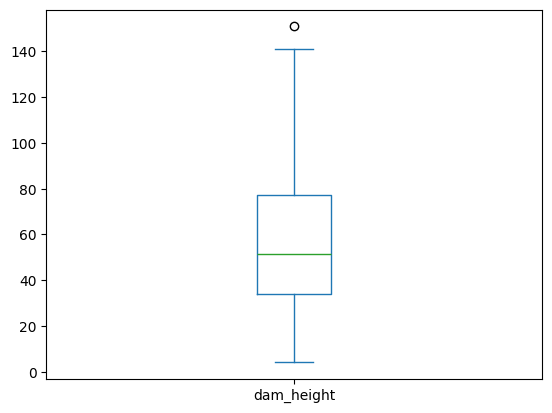

In [19]:
detailed_reservoirs_pd['dam_height'].plot.box()

There is only one outlier, and half the reservoirs have a dam height between 40 and 80 meters

And now an histogram to see another type of distribution:

<Axes: ylabel='Frequency'>

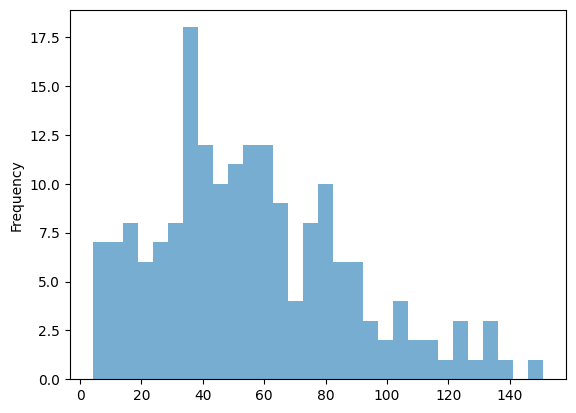

In [20]:
detailed_reservoirs_pd['dam_height'].plot(kind='hist', bins=30, alpha=0.6)

- At modeling/missing_values_imputation.ipynb it has been tried to develop several types of Random Forest Regressors to impute missing values in the dam height column. 
- As the predictions turned out to be random, it was decided to leave the missing values as they were.
- Nevertheless, the type of reservoir is the only column to seem to have a significant impact on the dam height, so it could be used if needed:

<Axes: title={'center': 'dam_height'}, xlabel='type'>

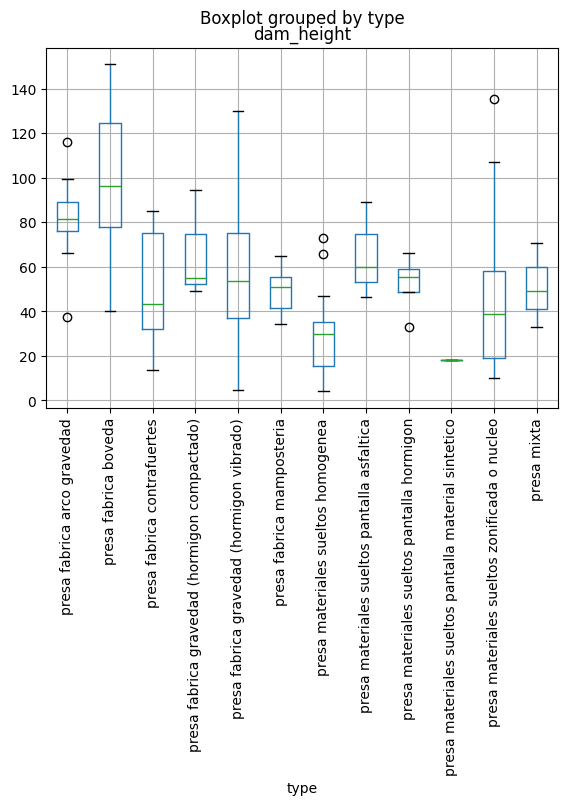

In [21]:
detailed_reservoirs_pd.boxplot(column='dam_height', by='type', rot=90)

So it could be imputed the median of the dam height by the type of reservoir if needed compulsory